# Fairness analyses

Kendra Wyant  
June 29, 2024

### Set Up Environment

In [ ]:

# handle conflicts
options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_ml.R?raw=true")


ℹ SHA-1 hash of file is "77e91675366f10788c6bcb59fa1cfc9ee0c75281"

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──
✔ broom        1.0.6      ✔ rsample      1.2.1 
✔ dials        1.2.1      ✔ tune         1.2.1 
✔ infer        1.0.7      ✔ workflows    1.1.4 
✔ modeldata    1.3.0      ✔ workflowsets 1.1.0 
✔ parsnip      1.2.1      ✔ yardstick    1.3.1 
✔ recipes      1.0.10     
── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Dig deeper into tidy modeling with R at https://www.tmwr.org

In [ ]:

devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "75cc6f7b855da59c240908bd936834b4da01285b"

In [ ]:
path_processed <- format_path(str_c("studydata/risk/data_processed/lag"))
path_models_lag <- format_path(str_c("studydata/risk/models/lag"))


### Read in Model Performance Metrics

In [ ]:
auroc_dem_0 <- read_csv(here::here(path_models_lag, "test_auroc_dem_6_x_5_1week_0_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)


auroc_dem_24 <- read_csv(here::here(path_models_lag, "test_auroc_dem_6_x_5_1week_24_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_72 <- read_csv(here::here(path_models_lag, "test_auroc_dem_6_x_5_1week_72_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_168 <- read_csv(here::here(path_models_lag, "test_auroc_dem_6_x_5_1week_168_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_336 <- read_csv(here::here(path_models_lag, "test_auroc_dem_6_x_5_1week_336_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)


### Get Median Posterior Probabilities and contrast analyses

function

In [ ]:
calc_pp <- function (lag, dem_var) {
  data_name <- str_c("auroc_dem_", lag)
  
  data <- 
    if (dem_var == "sex") {
    get(data_name) |> 
    select(id = repeat_num, id2 = fold_num, female, male)
  } else if (dem_var == "income") {
    get(data_name) |> 
    select(id = repeat_num, id2 = fold_num, `below poverty`,`above poverty`)
  } else if (dem_var == "race") {
    get(data_name) |> 
    select(id = repeat_num, id2 = fold_num, `not white`, `non-hispanic white` = white)
  } else {
    stop(dem_var, " not in data")
  }
  
  
  set.seed(101)
  pp <- data |> 
    perf_mod(formula = statistic ~ model + (1 | id2/id),
             transform = tidyposterior::logit_trans,  
             iter = 2000, chains = 4,  
             adapt_delta = .99,
             family = gaussian) 

  pp_tidy <- pp |> 
    tidy(seed = 123)

  q = c(.025, .5, .975)
  ci <- pp_tidy |> 
    group_by(model) |> 
    summarize(pp_median = quantile(posterior, probs = q[2]),
              pp_lower = quantile(posterior, probs = q[1]), 
              pp_upper = quantile(posterior, probs = q[3]))  |> 
    mutate(lag = lag) |> 
    arrange(model)
  
  
  contrast_lists <- 
    if (dem_var == "sex") {
    c(list("male"), list("female"))
  } else if (dem_var == "income") {
    c(list("above poverty"), list("below poverty"))
  } else if (dem_var == "race") {
    c(list("non-hispanic white"), list("not white"))
  } else {
    stop(dem_var, " not in data")
  }
      
  ci_contrast <- pp |>
    contrast_models(contrast_lists[1],  contrast_lists[2]) |> 
  summary(size = 0) 
  
  ci_median_contrast <- pp |> 
    contrast_models(contrast_lists[1],  contrast_lists[2]) |>  
    group_by(contrast) |> 
    summarize(median = quantile(difference, .5)) |> 
    mutate(contrast = str_remove(contrast, "\\."))


ci_contrast <- ci_contrast |> 
    mutate(lag = lag) |> 
    left_join(ci_median_contrast, by = c("contrast")) |> 
    select(contrast, probability, median, lower, upper, lag) 
  
  list(ci = ci, ci_contrast = ci_contrast)
}


sex

In [ ]:
sex <- c(0, 24,72,168,336) |> 
  map(\(lag) calc_pp(lag, "sex")) 



SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.1e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.61 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1.399 seconds (Warm-up)
Chain 1:                0.46 seconds (Sampling)
Chain 1:                1.859

# A tibble: 10 × 5
   model  pp_median pp_lower pp_upper   lag
   <chr>      <dbl>    <dbl>    <dbl> <dbl>
 1 female     0.867    0.847    0.885     0
 2 male       0.926    0.914    0.936     0
 3 female     0.849    0.827    0.869    24
 4 male       0.921    0.908    0.932    24
 5 female     0.836    0.813    0.856    72
 6 male       0.916    0.903    0.927    72
 7 female     0.823    0.801    0.845   168
 8 male       0.920    0.907    0.930   168
 9 female     0.788    0.760    0.815   336
10 male       0.905    0.890    0.918   336

# A tibble: 5 × 6
  contrast       probability median  lower  upper   lag
  <chr>                <dbl>  <dbl>  <dbl>  <dbl> <dbl>
1 male vs female           1 0.0589 0.0433 0.0747     0
2 male vs female           1 0.0714 0.0536 0.0901    24
3 male vs female           1 0.0802 0.0621 0.100     72
4 male vs female           1 0.0962 0.0774 0.116    168
5 male vs female           1 0.116  0.0936 0.140    336

income

In [ ]:
income <- c(0, 24,72,168,336) |> 
  map(\(lag) calc_pp(lag, "income")) 



SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 2.4e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.24 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.657 seconds (Warm-up)
Chain 1:                0.422 seconds (Sampling)
Chain 1:                1.07

# A tibble: 10 × 5
   model         pp_median pp_lower pp_upper   lag
   <chr>             <dbl>    <dbl>    <dbl> <dbl>
 1 above poverty     0.903    0.874    0.926     0
 2 below poverty     0.812    0.757    0.856     0
 3 above poverty     0.892    0.864    0.913    24
 4 below poverty     0.805    0.759    0.843    24
 5 above poverty     0.884    0.856    0.908    72
 6 below poverty     0.792    0.744    0.834    72
 7 above poverty     0.882    0.856    0.904   168
 8 below poverty     0.749    0.700    0.794   168
 9 above poverty     0.860    0.831    0.884   336
10 below poverty     0.729    0.680    0.770   336

# A tibble: 5 × 6
  contrast                       probability median  lower upper   lag
  <chr>                                <dbl>  <dbl>  <dbl> <dbl> <dbl>
1 above poverty vs below poverty           1 0.0908 0.0509 0.135     0
2 above poverty vs below poverty           1 0.0864 0.0504 0.125    24
3 above poverty vs below poverty           1 0.0919 0.0540 0.133    72
4 above poverty vs below poverty           1 0.133  0.0925 0.175   168
5 above poverty vs below poverty           1 0.131  0.0929 0.172   336

race

In [ ]:
race <- c(0, 24,72,168,336) |> 
  map(\(lag) calc_pp(lag, "race")) 



SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 2.5e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.25 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.812 seconds (Warm-up)
Chain 1:                0.435 seconds (Sampling)
Chain 1:                1.24

# A tibble: 10 × 5
   model              pp_median pp_lower pp_upper   lag
   <chr>                  <dbl>    <dbl>    <dbl> <dbl>
 1 non-hispanic white     0.905    0.857    0.938     0
 2 not white              0.736    0.622    0.822     0
 3 non-hispanic white     0.894    0.829    0.938    24
 4 not white              0.713    0.580    0.815    24
 5 non-hispanic white     0.886    0.843    0.918    72
 6 not white              0.727    0.644    0.792    72
 7 non-hispanic white     0.881    0.847    0.908   168
 8 not white              0.733    0.668    0.786   168
 9 non-hispanic white     0.857    0.819    0.888   336
10 not white              0.749    0.691    0.802   336

# A tibble: 5 × 6
  contrast                        probability median  lower upper   lag
  <chr>                                 <dbl>  <dbl>  <dbl> <dbl> <dbl>
1 non-hispanic white vs not white        1     0.168 0.0933 0.257     0
2 non-hispanic white vs not white        1.00  0.179 0.0901 0.283    24
3 non-hispanic white vs not white        1     0.159 0.100  0.227    72
4 non-hispanic white vs not white        1     0.148 0.0995 0.201   168
5 non-hispanic white vs not white        1     0.107 0.0643 0.152   336

Bind all pp/contrast tibbles and save

In [ ]:
pp_sex |> 
  bind_rows(pp_income) |> 
  bind_rows(pp_race) |> 
  write_csv(here::here(path_models_lag, "pp_dem_all.csv"))

pp_dem_contrast <- contrast_sex |> 
  bind_rows(contrast_income) |> 
  bind_rows(contrast_race) |> 
  write_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"))


### Figure for manuscript

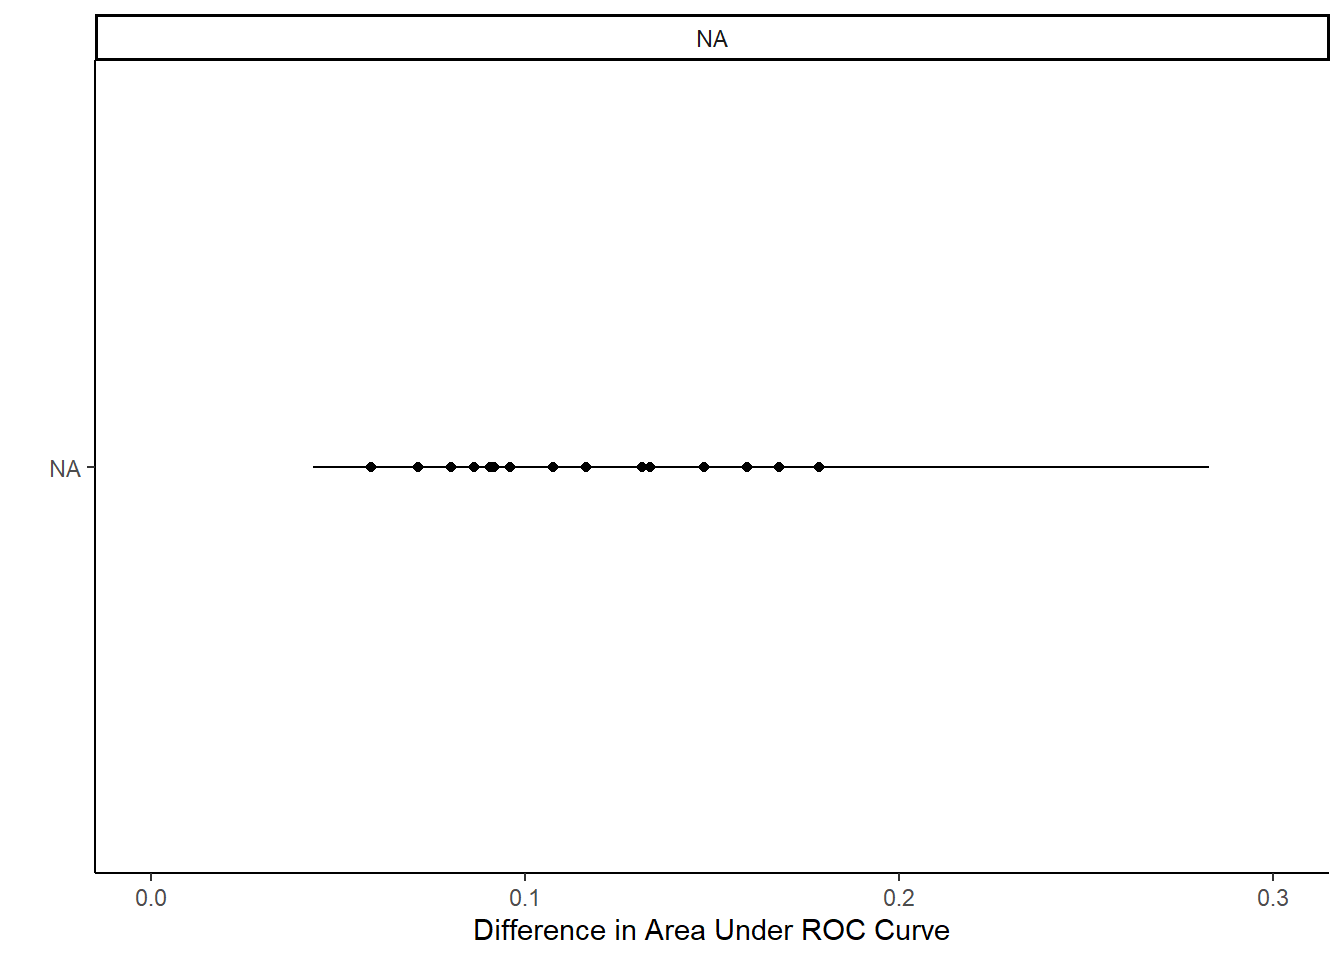

In [ ]:

pp_dem_contrast |>
  mutate(lag = factor(lag, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
         contrast = factor(contrast, levels = c("non-hispanic white vs. not white",
                                                "male vs. female",
                                                "above poverty vs. below poverty"),
                           labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty"))) |> 
  ggplot() + 
  geom_point(aes(x = median, y = lag), color = "black") +
  geom_segment(mapping = aes(y = lag, x = lower, xend = upper),
                data = pp_dem_contrast |>
                 mutate(lag = factor(lag, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
                 contrast = factor(contrast, levels = c("non-hispanic white vs. not white",
                                                "male vs. female",
                                                "above poverty vs. below poverty"),
                                    labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty")))) +
  facet_grid(~contrast) +
  scale_x_continuous("Difference in Area Under ROC Curve", limits = c(0, .3), breaks = c(0, .1, .2, .3)) +
  ylab("") +
  theme_classic() +
  theme(legend.position = "none")
